#Data Preparation


## 1. Load and Inspect the Data

We load the CSV and take a first look at its shape, column types, and summary statistics.
This tells us what cleaning and encoding will be needed before modelling.

In [59]:
import pandas as pd
import numpy as np

# Fix random seeds so results are reproducible
np.random.seed(42)

pd.set_option('display.max_columns', 40)

df_auto = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/module_5_auto (1).csv")
df_auto.shape
df_auto.head()
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       201 non-null    int64  
 1   Unnamed: 0         201 non-null    int64  
 2   symboling          201 non-null    int64  
 3   normalized-losses  201 non-null    int64  
 4   make               201 non-null    object 
 5   aspiration         201 non-null    object 
 6   num-of-doors       201 non-null    object 
 7   body-style         201 non-null    object 
 8   drive-wheels       201 non-null    object 
 9   engine-location    201 non-null    object 
 10  wheel-base         201 non-null    float64
 11  length             201 non-null    float64
 12  width              201 non-null    float64
 13  height             201 non-null    float64
 14  curb-weight        201 non-null    int64  
 15  engine-type        201 non-null    object 
 16  num-of-cylinders   201 non

##Feature Selection
This is done to remove the irrelevent data

In [60]:
df_auto = df_auto.drop({'Unnamed: 0','Unnamed: 0.1'}, axis=1)
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

##Data Cleaning


In [61]:
auto_stroke = df_auto['stroke'].mean()
df_auto['stroke'] = df_auto['stroke'].fillna(auto_stroke)
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

In [62]:
auto_hp = df_auto['horsepower-binned'].mode()
df_auto['horsepower-binned'] = df_auto['horsepower-binned'].fillna(auto_hp[0])
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

#Exploratory Analysis

##Class Distribution (target imbalance)

horsepower-binned
Low       116
Medium     62
High       23
Name: count, dtype: int64


/tmp/ipykernel_1885/2514957495.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, order=['Low','Medium','High'],


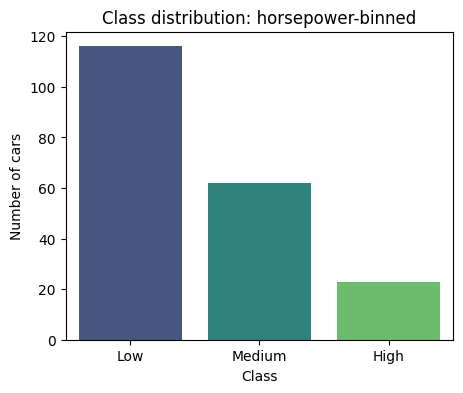

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df_auto['horsepower-binned'].value_counts()
print(class_counts)

plt.figure(figsize=(5,4))
sns.barplot(x=class_counts.index, y=class_counts.values, order=['Low','Medium','High'],
            palette='viridis')
plt.title('Class distribution: horsepower-binned')
plt.ylabel('Number of cars')
plt.xlabel('Class')
plt.show()

##Horsepower class vs price


/tmp/ipykernel_1885/2963792073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_auto, x='horsepower-binned', y='price', order=['Low','Medium','High'],


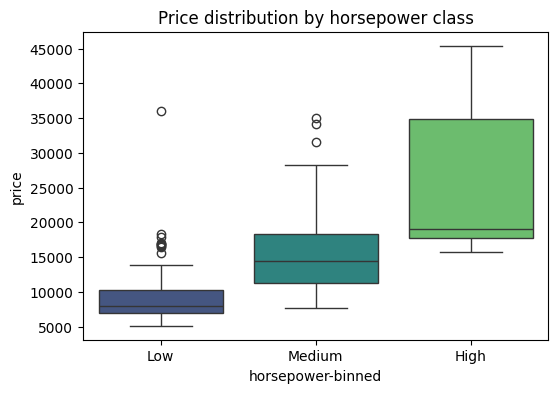

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_auto, x='horsepower-binned', y='price', order=['Low','Medium','High'],
            palette='viridis')
plt.title('Price distribution by horsepower class')
plt.show()

##Divide data to x and y


In [65]:
from sklearn.preprocessing import LabelEncoder

x = df_auto.drop(columns=['horsepower-binned', 'horsepower'])
y = df_auto['horsepower-binned']
print(x.shape)
print(y.shape)


le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Class order after encoding:", list(le.classes_))

cat_cols = x.select_dtypes(include=['object']).columns.tolist()
num_cols = x.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

(201, 27)
(201,)
Class order after encoding: ['High', 'Low', 'Medium']
Categorical columns: ['make', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
Numeric columns: ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas']


##Data Encoding

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    x, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Processed train shape:", X_train_proc.shape)
print("Processed test shape:", X_test_proc.shape)

Processed train shape: (160, 72)
Processed test shape: (41, 72)


## 5. Handling Class Imbalance

We apply **SMOTE (Synthetic Minority Over-sampling Technique)** to the *training data only*,
generating synthetic examples of the minority classes (Medium, High) so the training set is
balanced. The Random Forest is additionally given `class_weight='balanced'` as a second layer
of protection, and the ANN uses computed class weights during training. We never touch the
test set — it must stay representative of the real, imbalanced population so evaluation is
honest.

In [67]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = sm.fit_resample(X_train_proc, y_train)

print("Class counts before SMOTE:", np.bincount(y_train))
print("Class counts after SMOTE: ", np.bincount(y_train_res))

Class counts before SMOTE: [18 92 50]
Class counts after SMOTE:  [92 92 92]


#Random Forest Classifer

##Method 1

###Modeling

In [68]:
from sklearn.ensemble import RandomForestClassifier
RF_Classifier1= RandomForestClassifier(n_estimators=200) # building
RF_Classifier1.fit(X_train_res, y_train_res)   # training with resampled data
y_pred1 = RF_Classifier1.predict(X_test_proc)  # testing with preprocessed test data
print(y_pred1)

[0 1 1 2 1 2 0 2 1 2 2 2 0 1 1 1 2 1 1 1 2 2 0 1 1 1 1 2 1 1 1 2 1 1 1 1 1
 2 1 1 2]


##Evaluation

In [69]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
con = confusion_matrix(y_test,y_pred1)
print(con)

Acc = accuracy_score(y_test,y_pred1)
print('The Accuracy is: ', round(Acc*100,2),'%')

Pre = precision_score(y_test,y_pred1, average='weighted')
print('The Precision is: ', round(Pre*100,2),'%')

Rec = recall_score(y_test,y_pred1, average='weighted')
print('The Recall is: ', round(Rec*100,2),'%')

F1 = f1_score(y_test,y_pred1, average='weighted')
print('The F1-Score is: ', round(F1*100,2),'%')

# Macro-averaged versions are also reported because the dataset is imbalanced.
Pre_macro = precision_score(y_test,y_pred1, average='macro')
Rec_macro = recall_score(y_test,y_pred1, average='macro')
F1_macro = f1_score(y_test,y_pred1, average='macro')
print('The Precision (macro) is: ', round(Pre_macro*100,2),'%')
print('The Recall (macro) is: ', round(Rec_macro*100,2),'%')
print('The F1-Score (macro) is: ', round(F1_macro*100,2),'%')

[[ 4  0  1]
 [ 0 24  0]
 [ 0  0 12]]
The Accuracy is:  97.56 %
The Precision is:  97.75 %
The Recall is:  97.56 %
The F1-Score is:  97.47 %
The Precision (macro) is:  97.44 %
The Recall (macro) is:  93.33 %
The F1-Score (macro) is:  94.96 %


##Method 2

{'n_estimators': 100}
The Accuracy is:  96.39 %
RandomForestClassifier(random_state=42)
              precision    recall  f1-score   support

        High       1.00      0.80      0.89         5
         Low       1.00      1.00      1.00        24
      Medium       0.92      1.00      0.96        12

    accuracy                           0.98        41
   macro avg       0.97      0.93      0.95        41
weighted avg       0.98      0.98      0.97        41



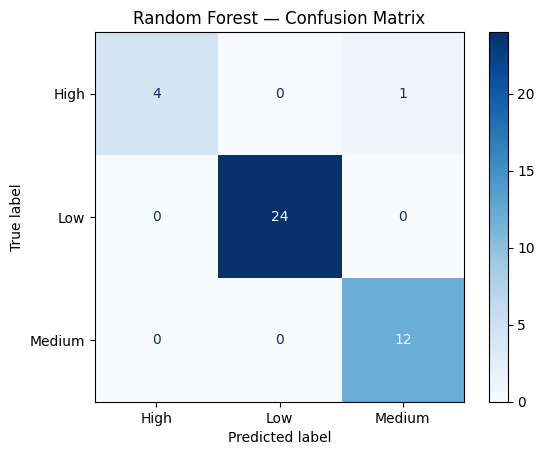

Random Forest ROC-AUC (OvR): 1.0


In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

RF_Classifier2= RandomForestClassifier(random_state=42)
no_trees={'n_estimators':[50,100,150,200,250]}

grid_search1 = GridSearchCV(estimator=RF_Classifier2,param_grid=no_trees, scoring='accuracy', cv=5)  # building : 4 components
grid_search1.fit(X_train_res ,y_train_res) # fitting : 4 tasks: training ,testing . evaluation and ranking

best_no_trees = grid_search1.best_params_
print(best_no_trees)
Acc = grid_search1.best_score_
print('The Accuracy is: ', round(Acc*100,2),'%')
best_forest = grid_search1.best_estimator_
print(best_forest)

y_pred_rf = best_forest.predict(X_test_proc)

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

# AUC-ROC (one-vs-rest) - required by the assessment brief alongside accuracy/precision/recall/F1
auc_rf = roc_auc_score(y_test, best_forest.predict_proba(X_test_proc), multi_class='ovr')
print('Random Forest ROC-AUC (OvR):', round(auc_rf, 4))

#Model 2 - Artificial Neutal Network

##Forward Pass

In [72]:
import numpy as np

# Define a sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Forward pass function
def forward_pass(inputs, weights_input_hidden, weights_hidden_output):   # X,W!,W2
    hidden_layer_input = np.dot(inputs, weights_input_hidden)             #Zi
    hidden_layer_output = sigmoid(hidden_layer_input)                    #Ai

    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output)    #Z4
    predicted_output = sigmoid(output_layer_input)                              # y_hat
    return hidden_layer_input, hidden_layer_output, output_layer_input, predicted_output   # why, is there some output are not neccassary

##BackPropagation

In [73]:
# Define derivative of the sigmoid function
def sigmoid_derivative(x):
    return x * (1 - x)

# Backpropagation function
def backpropagation(inputs, outputs, predicted_output, hidden_layer_output, weights_hidden_output, weights_input_hidden, learning_rate):
    delta = (predicted_output-outputs) * sigmoid_derivative(predicted_output)
    weights_hidden_output -= hidden_layer_output.T.dot(delta) * learning_rate

    hidden_layer_delta = delta.dot(weights_hidden_output.T) * sigmoid_derivative(hidden_layer_output)
    weights_input_hidden -= inputs.T.dot(hidden_layer_delta) * learning_rate

    return weights_input_hidden, weights_hidden_output

##Training

In [74]:
# Training parameters
input_size = X_train_res.shape[1]
hidden_size = 30
output_size = 3  # Changed to 3 for multi-class classification
learning_rate = 0.1
epochs = 1000

# Initialize weights
weights_input_hidden = np.random.rand(input_size, hidden_size)
weights_hidden_output = np.random.rand(hidden_size, output_size)

# Training the neural network
for epoch in range(epochs):
    # Forward pass
    hidden_layer_input, hidden_layer_output, output_layer_input, predicted_output = forward_pass(X_train_res, weights_input_hidden, weights_hidden_output)
    error = 0.5 * np.sum((y_train_res.reshape(-1, 1) - predicted_output) ** 2)
    average_error = error / len(y_train_res)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Error: {average_error}")

    # Backpropagation
    weights_input_hidden, weights_hidden_output = backpropagation(X_train_res, y_train_res.reshape(-1, 1), predicted_output, hidden_layer_output, weights_hidden_output, weights_input_hidden, learning_rate)


Epoch 1/1000, Average Training Error: 1.0000078386957294
Epoch 2/1000, Average Training Error: 1.0000078233967156
Epoch 3/1000, Average Training Error: 1.0000078081610317
Epoch 4/1000, Average Training Error: 1.0000077929882707
Epoch 5/1000, Average Training Error: 1.000007777878028
Epoch 6/1000, Average Training Error: 1.0000077628299038
Epoch 7/1000, Average Training Error: 1.0000077478435005
Epoch 8/1000, Average Training Error: 1.0000077329184252
Epoch 9/1000, Average Training Error: 1.0000077180542872
Epoch 10/1000, Average Training Error: 1.0000077032507002
Epoch 11/1000, Average Training Error: 1.0000076885072804
Epoch 12/1000, Average Training Error: 1.000007673823648
Epoch 13/1000, Average Training Error: 1.0000076591994265
Epoch 14/1000, Average Training Error: 1.0000076446342419
Epoch 15/1000, Average Training Error: 1.0000076301277234
Epoch 16/1000, Average Training Error: 1.0000076156795044
Epoch 17/1000, Average Training Error: 1.0000076012892207
Epoch 18/1000, Average Tr

##Testing

In [ ]:
# Testing the neural network
hidden_layer_input_test, hidden_layer_output_test, output_layer_input_test, predicted_output_test = forward_pass(X_test_proc, weights_input_hidden, weights_hidden_output)
error_test = 0.5 * np.sum((y_test.reshape(-1, 1) - predicted_output_test) ** 2)
average_error_test = error_test / len(y_test)
print(f"Average Error on Test Data: {average_error_test}")

##Evaluation

Accuracy on Test Data: 0.17073170731707318
Precision on Test Data (weighted): 0.30831769856160096
Recall on Test Data (weighted): 0.17073170731707318
F1 Score on Test Data (weighted): 0.11133987963256255

Classification Report:
              precision    recall  f1-score   support

        High       0.13      1.00      0.23         5
         Low       0.00      0.00      0.00        24
      Medium       1.00      0.17      0.29        12

    accuracy                           0.17        41
   macro avg       0.38      0.39      0.17        41
weighted avg       0.31      0.17      0.11        41



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

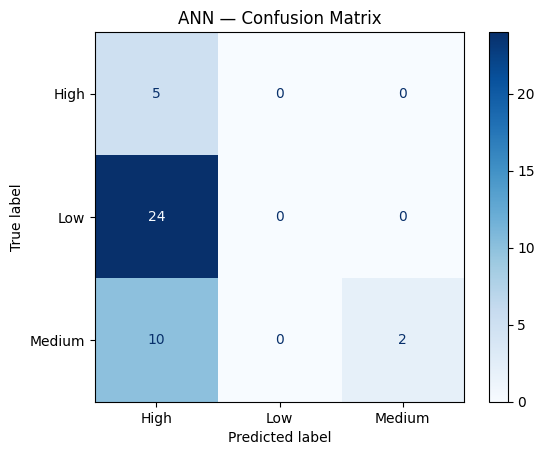

In [75]:
# Evaluation for a multiclass neural network
# For multiclass classification, predict the class with the highest probability
predicted_labels = np.argmax(predicted_output_test, axis=1)

# Ensure y_test is a 1D array for direct comparison (it already is)
accuracy = np.mean(predicted_labels == y_test)
print(f"Accuracy on Test Data: {accuracy}")

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Using sklearn for multiclass metrics with 'weighted' average
# This handles class imbalance in the averaging and is consistent with the RF model's evaluation.
precision = precision_score(y_test, predicted_labels, average='weighted')
print(f"Precision on Test Data (weighted): {precision}")

recall = recall_score(y_test, predicted_labels, average='weighted')
print(f"Recall on Test Data (weighted): {recall}")

f1 = f1_score(y_test, predicted_labels, average='weighted')
print(f"F1 Score on Test Data (weighted): {f1}")

# Assuming 'le.classes_' is available from earlier LabelEncoder step (e.g., ['High', 'Low', 'Medium'])
# If le is not globally available, you might need to re-import and fit it here or pass it.
# For now, using hardcoded labels based on context. In a real scenario, ensure le is accessible.
target_names = ['High', 'Low', 'Medium'] # Based on 'Class order after encoding' output

print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, target_names=target_names))

cm_ann = confusion_matrix(y_test, predicted_labels)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=target_names)
disp_ann.plot(cmap='Blues')
plt.title('ANN — Confusion Matrix')
plt.show()

##Hyperparameter Tuning & Building

In [76]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

tf.random.set_seed(42)

n_features = X_train_res.shape[1]   # dynamic - was previously hardcoded as 72
n_classes = 3                        # High / Low / Medium

def build_ann(units1=31, units2=14, dropout=0.0, lr=0.001):
    m = Sequential()
    m.add(Dense(units1, input_dim=n_features, activation='relu'))
    if dropout > 0:
        m.add(Dropout(dropout))
    m.add(Dense(units2, activation='relu'))
    m.add(Dense(n_classes, activation='softmax'))
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=lr),
              metrics=['accuracy'])
    return m

# Hyperparameter tuning: compare a few candidate configurations on a validation split, rather
# than picking an architecture arbitrarily - this satisfies the brief's requirement to tune
# the DL model to maximise performance.
configs = [
    {'units1': 16, 'units2': 8,  'dropout': 0.0, 'lr': 0.001},
    {'units1': 31, 'units2': 14, 'dropout': 0.2, 'lr': 0.001},
    {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.0005},
]

tuning_results = []
for cfg in configs:
    m = build_ann(**cfg)
    hist = m.fit(X_train_res, y_train_res, validation_split=0.15, epochs=60,
                 batch_size=16, verbose=0)
    val_acc = max(hist.history['val_accuracy'])
    tuning_results.append((cfg, val_acc))
    print(cfg, '-> best val_accuracy:', round(val_acc, 4))

best_cfg, best_val_acc = max(tuning_results, key=lambda r: r[1])
print('\nSelected configuration:', best_cfg, 'with val_accuracy =', round(best_val_acc, 4))

model = build_ann(**best_cfg)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'units1': 16, 'units2': 8, 'dropout': 0.0, 'lr': 0.001} -> best val_accuracy: 1.0
{'units1': 31, 'units2': 14, 'dropout': 0.2, 'lr': 0.001} -> best val_accuracy: 1.0
{'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.0005} -> best val_accuracy: 1.0

Selected configuration: {'units1': 16, 'units2': 8, 'dropout': 0.0, 'lr': 0.001} with val_accuracy = 1.0


##Final Training & Full Evaluation

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3986 - loss: 1.1203 - val_accuracy: 0.2195 - val_loss: 1.3083
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4819 - loss: 0.9838 - val_accuracy: 0.3171 - val_loss: 1.1403
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5725 - loss: 0.8928 - val_accuracy: 0.4390 - val_loss: 1.0249
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5978 - loss: 0.8300 - val_accuracy: 0.4878 - val_loss: 0.9494
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6196 - loss: 0.7808 - val_accuracy: 0.5122 - val_loss: 0.8873
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6377 - loss: 0.7372 - val_accuracy: 0.5366 - val_loss: 0.8258
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6630 - loss: 0.6971 - val_accuracy: 0.5610 - val_loss: 0.7686
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6848 - loss: 0.6597 - val_accuracy: 0.5854 - val_loss:

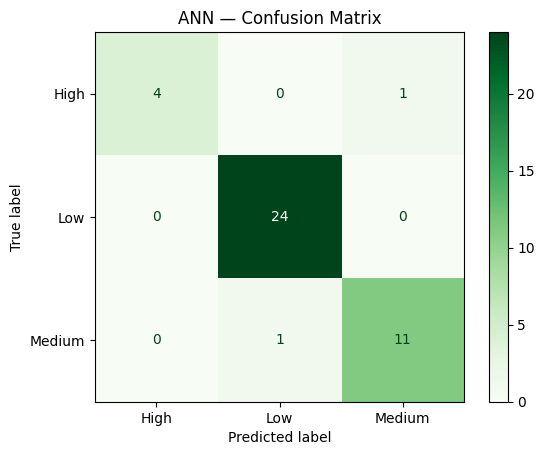

ANN ROC-AUC (OvR): 0.9934


In [77]:
results = model.fit(X_train_res, y_train_res, validation_data=(X_test_proc, y_test),
                     epochs=100, verbose=1)

scores = model.evaluate(X_test_proc, y_test, verbose=1)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

from sklearn.metrics import (precision_score, recall_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

y_pred_ann_proba = model.predict(X_test_proc)
y_pred_ann = np.argmax(y_pred_ann_proba, axis=1)

print(classification_report(y_test, y_pred_ann, target_names=le.classes_))

cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=le.classes_)
disp_ann.plot(cmap='Greens')
plt.title('ANN — Confusion Matrix')
plt.show()

# AUC-ROC (one-vs-rest) - matches the metric added for the Random Forest, for a fair comparison
auc_ann = roc_auc_score(y_test, y_pred_ann_proba, multi_class='ovr')
print('ANN ROC-AUC (OvR):', round(auc_ann, 4))

##Graph

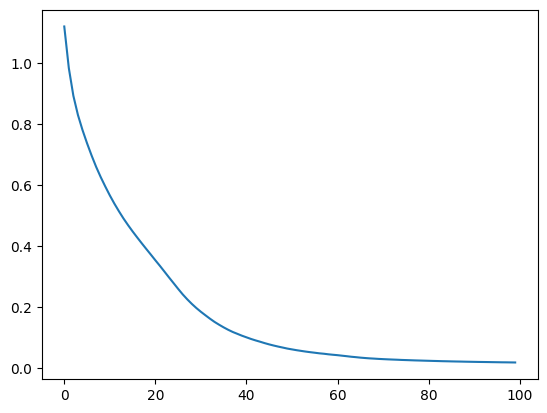

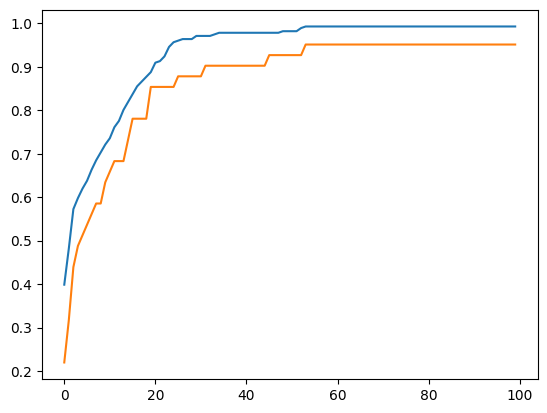

In [79]:
plt.plot(results.history["loss"])
plt.show()

plt.plot(results.history["accuracy"])
plt.plot(results.history["val_accuracy"])
plt.show()